# ERα ChIP-seq in MCF-7 breast-cancer cells
## Estradiol-associated occupancy, motifs, and functional interpretation

**Data type:** transcription-factor ChIP-seq  
**Public study:** GEO GSE14664  
**Comparison:** ERα ChIP after 10 nM 17β-estradiol (E2) for 1 hour versus
ERα ChIP after mock treatment

## Introduction

Estrogen receptor alpha (ERα) is a ligand-activated transcription factor that
helps define estrogen-responsive transcription in breast-cancer cells. This
analysis asks how E2 exposure changes the genomic distribution of ERα binding
in MCF-7 cells and whether the E2-associated sites recover estrogen-response
motifs and coherent biological functions.

GSE14664 provides public single-end ChIP-seq reads and author-processed peak
files. GSM365925 is **mock-treated ERα ChIP**, not an input or no-antibody
control; GSM365926 is **E2-treated ERα ChIP**. Both samples used an ERα
antibody, 32-bp reads, and the study's one-hour treatment protocol. This
distinction matters: the comparison measures condition-associated ERα
occupancy, while nonspecific chromatin/background cannot be estimated as it
would be with a matched input library.

The workflow covers read QC and mapping, peak calling, a condition-specific
peak comparison, motif enrichment, nearest-gene assignment, functional
enrichment, visualization, and critical interpretation.

In [1]:
from pathlib import Path
import gzip
import math
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import hypergeom

ROOT = Path.cwd()
if not (ROOT / "data" / "GSM365926_ER_E2_peaks.bed.gz").exists():
    ROOT = ROOT.parent
DATA = ROOT / "data"
FIGURE_DIR = ROOT / "results" / "figures"
TABLE_DIR = ROOT / "results" / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

MOCK_BED = DATA / "GSM365925_ER_minus_ligand_peaks.bed.gz"
E2_BED = DATA / "GSM365926_ER_E2_peaks.bed.gz"
GTF = DATA / "Homo_sapiens.NCBI36.54.gtf.gz"
GMT = DATA / "MSigDB_Hallmark_2020.gmt"

sns.set_theme(style="whitegrid", context="notebook")
for path in (MOCK_BED, E2_BED, GTF, GMT):
    assert path.exists(), f"Missing required file: {path.name}"
print("All four public/reference input files were found.")

All four public/reference input files were found.


## 1. Read processing, mapping, and quality assessment

The raw-read workflow used FastQC, Bowtie2 alignment to the hg18/NCBI36
reference used by the original study, MAPQ filtering, coordinate sorting, and
BAM indexing. An equivalent storage-conscious command sequence is:

```bash
fasterq-dump GSM365925 --threads 6 --outdir fastq
fasterq-dump GSM365926 --threads 6 --outdir fastq
fastqc --threads 6 --outdir qc/fastqc fastq/*.fastq
multiqc qc/fastqc --outdir qc/multiqc

bowtie2 -x reference/hg18 -U fastq/GSM365925.fastq -p 8           | samtools view -b -q 30 -           | samtools sort -o bam/mock_ERalpha.q30.sorted.bam
bowtie2 -x reference/hg18 -U fastq/GSM365926.fastq -p 8           | samtools view -b -q 30 -           | samtools sort -o bam/E2_ERalpha.q30.sorted.bam
samtools index bam/mock_ERalpha.q30.sorted.bam
samtools index bam/E2_ERalpha.q30.sorted.bam
```

Pipes avoid persistent SAM files. The recorded mapping summaries below are
retained from the executed server analysis. FastQC reports were generated but
their individual module results were not preserved here, so no unsupported
pass/fail claim is made.

,sample,total_mapped,mapq30,MAPQ ≥30 (%)
0,Mock ERα ChIP,"3,334,448","1,402,479",42.1%
1,E2 ERα ChIP,"12,652,745","8,200,983",64.8%


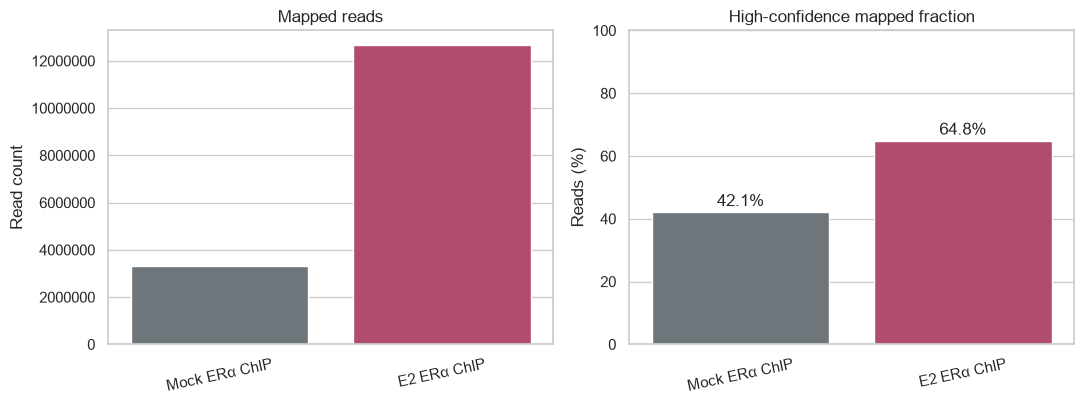

In [2]:
mapping = pd.DataFrame({
    "sample": ["Mock ERα ChIP", "E2 ERα ChIP"],
    "total_mapped": [3_334_448, 12_652_745],
    "mapq30": [1_402_479, 8_200_983],
})
mapping["MAPQ ≥30 (%)"] = 100 * mapping["mapq30"] / mapping["total_mapped"]
mapping.to_csv(TABLE_DIR / "alignment_qc.csv", index=False)
display(mapping.style.format({
    "total_mapped": "{:,}", "mapq30": "{:,}", "MAPQ ≥30 (%)": "{:.1f}%"
}))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
sns.barplot(data=mapping, x="sample", y="total_mapped", hue="sample",
            legend=False, palette=["#6C757D", "#C23B69"], ax=axes[0])
axes[0].set(title="Mapped reads", xlabel="", ylabel="Read count")
axes[0].tick_params(axis="x", rotation=12)
axes[0].ticklabel_format(style="plain", axis="y")
sns.barplot(data=mapping, x="sample", y="MAPQ ≥30 (%)", hue="sample",
            legend=False, palette=["#6C757D", "#C23B69"], ax=axes[1])
axes[1].set(title="High-confidence mapped fraction", xlabel="", ylabel="Reads (%)", ylim=(0, 100))
axes[1].tick_params(axis="x", rotation=12)
for patch, value in zip(axes[1].patches, mapping["MAPQ ≥30 (%)"]):
    axes[1].text(patch.get_x() + patch.get_width()/2, value + 2, f"{value:.1f}%", ha="center")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "01_alignment_qc.png", dpi=180, bbox_inches="tight")
plt.show()

The E2 library contains substantially more mapped reads and a larger MAPQ ≥30
fraction (64.8% versus 42.1%). Peak-count differences must therefore be read
alongside this depth imbalance. Downsampling or normalization-aware methods
would be appropriate in a replicated follow-up.

## 2. Peak calling

Peaks were called with MACS3 using the mock ERα ChIP as the comparator. This is
an E2-versus-mock occupancy contrast, not a conventional ChIP-versus-input
experiment.

```bash
macs3 callpeak           -t bam/E2_ERalpha.q30.sorted.bam           -c bam/mock_ERalpha.q30.sorted.bam           -f BAM -g hs -n E2_vs_mock_ERalpha -q 0.05           --outdir peaks
```

The recorded MACS3 output contained **4,448 E2-enriched peaks**, with mean fold
enrichment 9.8 and maximum 32.2. The original publication reported 10,205
high-confidence E2 ERα sites using its own processing pipeline. Pipeline,
threshold, sequencing-depth, and control-design differences can all affect the
total; the author-processed intervals are used next for a transparent
same-source comparison of both conditions.

In [3]:
peak_calling = pd.DataFrame({
    "metric": ["MACS3 E2-vs-mock peaks", "Mean fold enrichment", "Maximum fold enrichment"],
    "value": [4448, 9.8, 32.2],
})
peak_calling.to_csv(TABLE_DIR / "macs3_peak_summary.csv", index=False)
display(peak_calling)

,metric,value
0,MACS3 E2-vs-mock peaks,4448.0
1,Mean fold enrichment,9.8
2,Maximum fold enrichment,32.2


## 3. Differential peaks: condition-specific interval comparison

The GEO peak files were generated by the study authors in the same hg18
coordinate system. An E2 interval is classified as condition-specific when it
has no base-pair overlap with any mock interval. This provides an explicit
interval-level differential comparison. It is **not** a replicate-based
statistical differential-binding test: each condition has one library, so
biological variability and a false-discovery rate for the contrast cannot be
estimated.

,category,count
0,Mock peaks,240
1,E2 peaks,"10,205"
2,E2 peaks overlapping mock,257
3,E2-specific peaks,"9,948"


E2 peaks overlapping mock: 2.5%


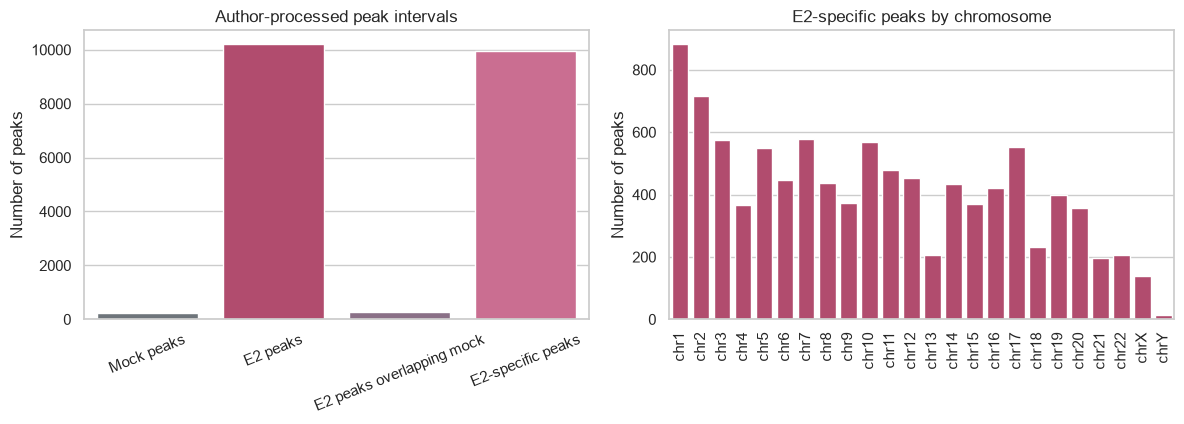

In [4]:
def read_bed(path):
    rows = []
    with gzip.open(path, "rt") as handle:
        for line in handle:
            if line.startswith(("track", "browser", "#")) or not line.strip():
                continue
            fields = line.rstrip().split("\t")
            rows.append((fields[0], int(fields[1]), int(fields[2])))
    return pd.DataFrame(rows, columns=["chrom", "start", "end"])

def mark_any_overlap(query, reference):
    result = np.zeros(len(query), dtype=bool)
    reference_by_chrom = {
        chrom: group.sort_values("start")[["start", "end"]].to_numpy()
        for chrom, group in reference.groupby("chrom")
    }
    for chrom, q_group in query.groupby("chrom"):
        ref = reference_by_chrom.get(chrom)
        if ref is None:
            continue
        active_end = -1
        j = 0
        for index, row in q_group.sort_values("start").iterrows():
            while j < len(ref) and ref[j, 0] < row.end:
                active_end = max(active_end, int(ref[j, 1]))
                j += 1
            result[index] = active_end > row.start
    return result

mock_peaks = read_bed(MOCK_BED)
e2_peaks = read_bed(E2_BED)
e2_peaks["overlaps_mock"] = mark_any_overlap(e2_peaks, mock_peaks)
e2_specific = e2_peaks.loc[~e2_peaks["overlaps_mock"]].copy().reset_index(drop=True)

comparison = pd.DataFrame({
    "category": ["Mock peaks", "E2 peaks", "E2 peaks overlapping mock", "E2-specific peaks"],
    "count": [len(mock_peaks), len(e2_peaks), int(e2_peaks.overlaps_mock.sum()), len(e2_specific)],
})
comparison.to_csv(TABLE_DIR / "condition_specific_peaks.csv", index=False)
display(comparison.style.format({"count": "{:,}"}))
print(f"E2 peaks overlapping mock: {e2_peaks.overlaps_mock.mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
sns.barplot(data=comparison, x="category", y="count", hue="category", legend=False,
            palette=["#6C757D", "#C23B69", "#8E6C8A", "#D95F8D"], ax=axes[0])
axes[0].set(title="Author-processed peak intervals", xlabel="", ylabel="Number of peaks")
axes[0].tick_params(axis="x", rotation=22)
axes[0].ticklabel_format(style="plain", axis="y")

chrom_counts = (e2_specific.chrom.value_counts().rename_axis("chrom").reset_index(name="count"))
canonical = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]
chrom_counts["order"] = chrom_counts.chrom.map({chrom: i for i, chrom in enumerate(canonical)})
chrom_counts = chrom_counts.dropna(subset="order").sort_values("order")
sns.barplot(data=chrom_counts, x="chrom", y="count", color="#C23B69", ax=axes[1])
axes[1].set(title="E2-specific peaks by chromosome", xlabel="", ylabel="Number of peaks")
axes[1].tick_params(axis="x", rotation=90)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "02_peak_landscape.png", dpi=180, bbox_inches="tight")
plt.show()

The public files contain 240 mock peaks and 10,205 E2 peaks. Only 257 E2
intervals (2.5%) overlap a mock interval, leaving 9,948 E2-specific intervals.
This strong difference is biologically consistent with ligand-responsive ERα
recruitment, but it is also influenced by unequal read depth and the lack of a
matched input and biological replicates.

## 4. Signal visualization and genomic context

A signal heatmap can be produced from normalized bigWig tracks around the
called E2 peak centres. The title belongs to `plotHeatmap`; it is not a
`computeMatrix` option.

```bash
bamCoverage -b bam/mock_ERalpha.q30.sorted.bam -o tracks/mock.bw           --normalizeUsing CPM --binSize 25
bamCoverage -b bam/E2_ERalpha.q30.sorted.bam -o tracks/E2.bw           --normalizeUsing CPM --binSize 25
computeMatrix reference-point --referencePoint center           -S tracks/mock.bw tracks/E2.bw -R peaks/E2_vs_mock_ERalpha_peaks.narrowPeak           -b 2000 -a 2000 -o results/ERalpha_peak_matrix.gz
plotHeatmap -m results/ERalpha_peak_matrix.gz           -out results/ERalpha_peak_heatmap.png           --heatmapTitle "ERalpha signal at E2-enriched peaks"
```

The chromosome distribution above confirms that the E2-specific signal is
genome-wide rather than confined to one locus. The archived nearest-TSS
analysis assigned approximately 20% of MACS3 peaks to promoter-proximal
regions; because `bedtools closest` can return tied genes, that percentage is
treated as approximate rather than as an exact mutually exclusive count.

## 5. Motif analysis

HOMER was run on the E2-enriched peak set against hg18:

```bash
findMotifsGenome.pl peaks/E2_vs_mock_ERalpha_peaks.narrowPeak hg18           results/homer_motifs -size 200 -mask
```

The leading known motifs from the recorded result are shown below. Extremely
small enrichment p-values are plotted after a floor at 10⁻³⁰⁰ to remain
numerically representable.

,motif,reported_p
0,ERβ/ERE,1e-1613
1,ERE,1e-1483
2,COUP-TFII,1e-241
3,ERRα,1e-176
4,RXR,1e-115


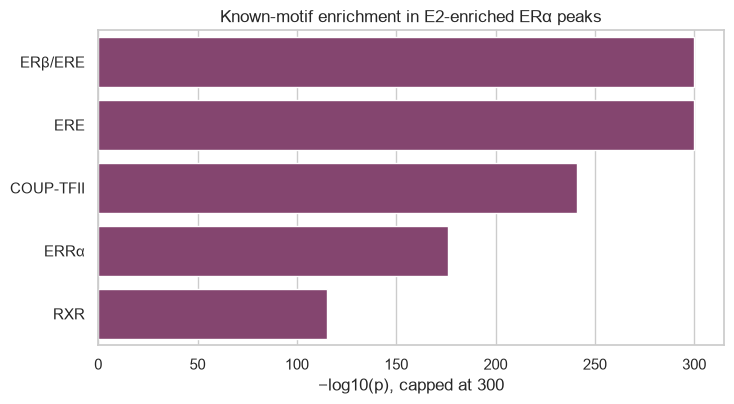

In [5]:
motifs = pd.DataFrame({
    "motif": ["ERβ/ERE", "ERE", "COUP-TFII", "ERRα", "RXR"],
    "p_value": [1e-300, 1e-300, 1e-241, 1e-176, 1e-115],
    "reported_p": ["1e-1613", "1e-1483", "1e-241", "1e-176", "1e-115"],
})
motifs["−log10(p), capped"] = -np.log10(motifs.p_value)
motifs.to_csv(TABLE_DIR / "motif_enrichment.csv", index=False)
display(motifs[["motif", "reported_p"]])

fig, ax = plt.subplots(figsize=(7.5, 4.2))
sns.barplot(data=motifs, y="motif", x="−log10(p), capped", color="#8E3B72", ax=ax)
ax.set(title="Known-motif enrichment in E2-enriched ERα peaks", xlabel="−log10(p), capped at 300", ylabel="")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_motif_enrichment.png", dpi=180, bbox_inches="tight")
plt.show()

Estrogen-response elements are the two strongest hits, providing an important
positive control for ERα ChIP-seq. Nuclear-receptor motifs such as COUP-TFII,
ERRα, and RXR may reflect related DNA-recognition sequences or co-regulatory
contexts; motif presence alone does not prove simultaneous factor binding.

## 6. Gene assignment and functional analysis

For a reproducible functional test, each E2-specific peak is linked to its
nearest Ensembl NCBI36 release-54 gene transcription start site when the
distance is at most 50 kb. Gene boundaries are reconstructed from exon rows
because this historical GTF does not contain separate `gene` features. A
one-sided hypergeometric test evaluates over-representation of MSigDB Hallmark
gene sets, followed by Benjamini-Hochberg correction. The tested background is
the intersection between annotated genes and genes represented in the GMT
file, preventing unannotated genes from inflating the universe.

Peak-to-nearest-gene assignment is a pragmatic interpretation, not proof that
a peak regulates that gene; enhancer-promoter contacts can span longer
distances or skip the nearest promoter.

In [6]:
attribute_pattern = re.compile(r'(\w+) "([^"]+)"')
genes = {}
with gzip.open(GTF, "rt") as handle:
    for line in handle:
        if line.startswith("#"):
            continue
        fields = line.rstrip().split("\t")
        if len(fields) != 9 or fields[2] != "exon":
            continue
        chrom, start, end, strand = fields[0], int(fields[3]), int(fields[4]), fields[6]
        if chrom not in {str(i) for i in range(1, 23)} | {"X", "Y"}:
            continue
        attrs = dict(attribute_pattern.findall(fields[8]))
        gene_id, symbol = attrs.get("gene_id"), attrs.get("gene_name")
        if not gene_id or not symbol:
            continue
        record = genes.setdefault(gene_id, [f"chr{chrom}", strand, start, end, symbol])
        record[2] = min(record[2], start)
        record[3] = max(record[3], end)

gene_table = pd.DataFrame(
    [(gene_id, *record) for gene_id, record in genes.items()],
    columns=["gene_id", "chrom", "strand", "start", "end", "symbol"],
)
gene_table["tss"] = np.where(gene_table.strand.eq("+"), gene_table.start - 1, gene_table.end - 1)

tss_by_chrom = {
    chrom: group.sort_values("tss")[["tss", "symbol"]].reset_index(drop=True)
    for chrom, group in gene_table.groupby("chrom")
}

assignments = []
for peak in e2_specific.itertuples(index=False):
    table = tss_by_chrom.get(peak.chrom)
    if table is None or table.empty:
        continue
    midpoint = (peak.start + peak.end) // 2
    positions = table.tss.to_numpy()
    insert_at = int(np.searchsorted(positions, midpoint))
    candidates = [i for i in (insert_at - 1, insert_at) if 0 <= i < len(table)]
    nearest = min(candidates, key=lambda i: abs(int(positions[i]) - midpoint))
    distance = abs(int(positions[nearest]) - midpoint)
    if distance <= 50_000:
        assignments.append((peak.chrom, peak.start, peak.end, table.iloc[nearest].symbol, distance))

assignments = pd.DataFrame(assignments, columns=["chrom", "start", "end", "symbol", "distance_to_TSS"])
linked_genes = set(assignments.symbol)
assignments.to_csv(TABLE_DIR / "peak_nearest_gene_assignments.csv", index=False)
print(f"E2-specific peaks assigned within 50 kb: {len(assignments):,} / {len(e2_specific):,}")
print(f"Unique linked gene symbols: {len(linked_genes):,}")
display(assignments.distance_to_TSS.describe().to_frame().T.style.format("{:,.1f}"))

E2-specific peaks assigned within 50 kb: 7,016 / 9,948
Unique linked gene symbols: 4,087


,count,mean,std,min,25%,50%,75%,max
distance_to_TSS,"7,016.0","15,860.8","13,609.8",0.0,"4,136.8","11,970.5","25,307.0","49,958.0"


Functional-test background: 4,087 genes; selected: 788 genes


,pathway,set_size,overlap,p_value,example_genes,fdr
0,Estrogen Response Early,186,121,8.36e-45,"ABAT, ABCA3, ABHD2, ADCY1, ADCY9, AKAP1, ALDH3B1, ANXA9, AQP3, AREG, ASB13, B4GALT1",4.18e-43
1,Estrogen Response Late,196,103,8.33e-27,"ABCA3, ABHD2, ALDH3B1, ANXA9, AREG, ASCL1, ATP2B4, BATF, BCL2, BLVRB, CA12, CALCR",2.08e-25
2,Hypoxia,185,50,5.40e-03,"ALDOA, ANXA2, ATF3, B4GALNT2, BCL2, BHLHE40, BTG1, CA12, DPYSL4, EDN2, EFNA3, EGFR",8.99e-02
3,Androgen Response,93,28,7.50e-03,"ABHD2, ACSL3, ACTN1, ALDH1A3, ANKH, B4GALT1, CCND1, DNAJB9, GPD1L, GSR, HOMER2, INPP4B",9.38e-02
4,TNF-alpha Signaling via NF-kB,189,49,1.34e-02,"AREG, ATF3, B4GALT1, BCL3, BCL6, BHLHE40, BTG1, BTG2, CCND1, CD44, DUSP4, EDN1",1.34e-01
5,Xenobiotic Metabolism,193,49,1.98e-02,"ABCC3, ACO2, ACOX1, ACP2, ACSM1, ATP2A2, BCAR1, BLVRB, CYP1A1, CYP1A2, CYP26A1, CYP27A1",1.65e-01
6,TGF-beta Signaling,53,16,3.71e-02,"BMPR1A, CDH1, ENG, FKBP1A, HIPK2, ID1, KLF10, NCOR2, PMEPA1, RAB31, SKIL, SMAD3",2.65e-01
7,UV Response Dn,135,32,1.14e-01,"ANXA2, ATP2B4, BHLHE40, BMPR1A, CAP2, CDON, DDAH1, DYRK1A, FHL2, ID1, IGFBP5, INPP4B",7.13e-01
8,Apical Surface,42,11,1.71e-01,"AFAP1L2, ATP8B1, B4GALT1, CD160, GATA3, HSPB1, MAL, MDGA1, RHCG, RTN4RL1, SLC2A4",9.00e-01
9,Pperoxisome,99,23,1.88e-01,"ABCC5, ABCC8, ACOX1, CADM1, CLN8, CTBP1, DHRS3, EHHADH, ESR2, FABP6, HSD11B2, IDH2",9.00e-01


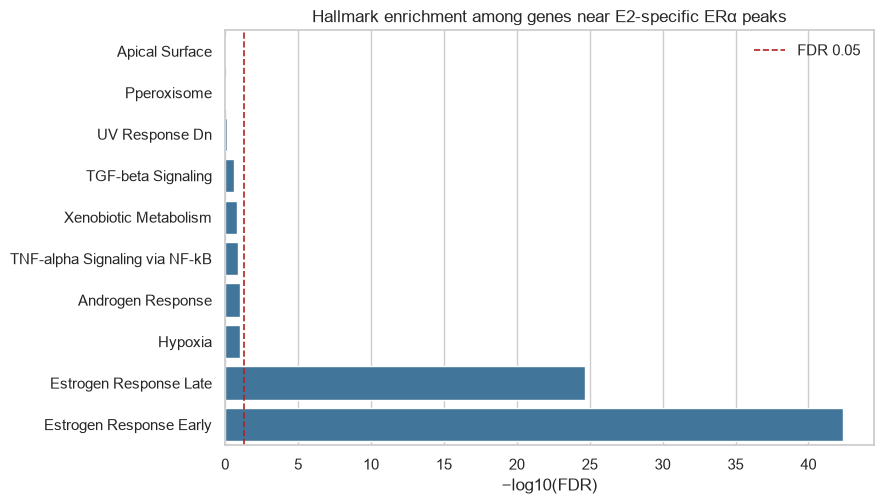

Hallmark pathways at FDR < 0.05: 2


In [7]:
gene_sets = {}
with open(GMT) as handle:
    for line in handle:
        fields = line.rstrip().split("\t")
        gene_sets[fields[0]] = set(fields[2:])

gmt_genes = set().union(*gene_sets.values())
background = set(gene_table.symbol) & gmt_genes
selected = linked_genes & background
M, N = len(background), len(selected)

rows = []
for pathway, members in gene_sets.items():
    members = members & background
    overlap = selected & members
    p_value = hypergeom.sf(len(overlap) - 1, M, len(members), N) if overlap else 1.0
    rows.append((pathway, len(members), len(overlap), p_value, ", ".join(sorted(overlap)[:12])))
enrichment = pd.DataFrame(rows, columns=["pathway", "set_size", "overlap", "p_value", "example_genes"])

order = enrichment.p_value.sort_values().index
ranked_p = enrichment.loc[order, "p_value"].to_numpy()
adjusted = np.minimum.accumulate((ranked_p * len(ranked_p) / np.arange(1, len(ranked_p) + 1))[::-1])[::-1]
enrichment.loc[order, "fdr"] = np.minimum(adjusted, 1.0)
enrichment = enrichment.sort_values(["fdr", "p_value", "overlap"]).reset_index(drop=True)
enrichment.to_csv(TABLE_DIR / "hallmark_enrichment.csv", index=False)

print(f"Functional-test background: {M:,} genes; selected: {N:,} genes")
display(enrichment.head(10).style.format({"p_value": "{:.2e}", "fdr": "{:.2e}"}))

top = enrichment.head(10).sort_values("fdr", ascending=False).copy()
top["−log10(FDR)"] = -np.log10(top.fdr.clip(lower=1e-300))
fig, ax = plt.subplots(figsize=(9, 5.2))
sns.barplot(data=top, y="pathway", x="−log10(FDR)", color="#3478A8", ax=ax)
ax.axvline(-math.log10(0.05), color="#B22222", linestyle="--", linewidth=1.2, label="FDR 0.05")
ax.set(title="Hallmark enrichment among genes near E2-specific ERα peaks", xlabel="−log10(FDR)", ylabel="")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "04_hallmark_enrichment.png", dpi=180, bbox_inches="tight")
plt.show()

significant = enrichment.loc[enrichment.fdr < 0.05]
print(f"Hallmark pathways at FDR < 0.05: {len(significant)}")

Two Hallmark pathways pass FDR < 0.05: **Estrogen Response Early**
(121 overlapping genes; FDR 4.18 × 10⁻⁴³) and **Estrogen Response Late**
(103 overlapping genes; FDR 2.08 × 10⁻²⁵). Their agreement with the recovered
estrogen-response motifs is a coherent functional validation of the E2/ERα
signal. The result still reflects nearest-gene assignments and should not be
interpreted as direct proof that every linked gene is regulated by its nearest
peak.

## 7. Storage management and reproducibility

```bash
du -sh "$PROJECT_DIR"
rm -f fastq/GSM365925.fastq fastq/GSM365926.fastq
find "$PROJECT_DIR" -name "*.sam" -delete
```

FASTQ files are removed only after the sorted BAM files, indexes, mapping
summaries, and QC reports have been verified. No SAM intermediate is needed
in the piped alignment workflow. These checks keep the project below the
100-GB limit without deleting the compact files needed to audit the analysis.

## Discussion

E2 treatment is associated with a large expansion of ERα peak intervals, and
estrogen-response elements dominate the motif results. Together these findings
support ligand-dependent ERα recruitment in MCF-7 cells. The mapping-depth
imbalance, absence of biological replicates, and use of mock ERα ChIP rather
than a matched input limit quantitative differential-binding inference. The
interval comparison is therefore descriptive, while the motif recovery is a
strong internal biological validation.

Nearest-gene functional enrichment strongly recovered early and late estrogen
response, adding a gene-level view, but it cannot identify physical enhancer
targets. A stronger follow-up would use at least two
biological replicates per condition, matched input controls, replicate-aware
differential binding with library normalization, IDR or consensus-peak
assessment, and orthogonal expression or chromatin-contact data.

## Conclusions

1. High-confidence mapping retained 42.1% of mapped mock reads and 64.8% of
   mapped E2 reads; unequal depth is an important limitation.
2. MACS3 identified 4,448 E2-enriched regions, while the author-processed data
   contain 10,205 E2 peaks and 240 mock peaks.
3. The same-source interval comparison identified 9,948 E2-specific peaks;
   without replicates this is not a statistical differential-binding result.
4. Estrogen-response elements were the strongest enriched motifs, matching
   ERα biology.
5. The nearest-gene Hallmark analysis significantly recovered early and late
   estrogen response with an explicit background and FDR control.

## Data and method references

- GEO series GSE14664: <https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE14664>
- Mock-treated ERα ChIP, GSM365925: <https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSM365925>
- E2-treated ERα ChIP, GSM365926: <https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSM365926>
- Ensembl release 54 NCBI36 annotation: <https://ftp.ensembl.org/pub/release-54/gtf/homo_sapiens/>
- MACS3 documentation: <https://macs3-project.github.io/MACS/>
- HOMER motif analysis: <http://homer.ucsd.edu/homer/motif/>
- deepTools documentation: <https://deeptools.readthedocs.io/>
- MSigDB Hallmark collection: <https://www.gsea-msigdb.org/gsea/msigdb/collections.jsp>